# Vlasov Two-Stream LaSDI-NM Example (Single Flattened AE)


In [1]:
import re
import time
from pathlib import Path

import numpy as np
import numpy.linalg as LA

import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

import modLaSDIUtils as lasdiutils
import modAutoEncoder as autoencoder
from LaSDI import LaSDI


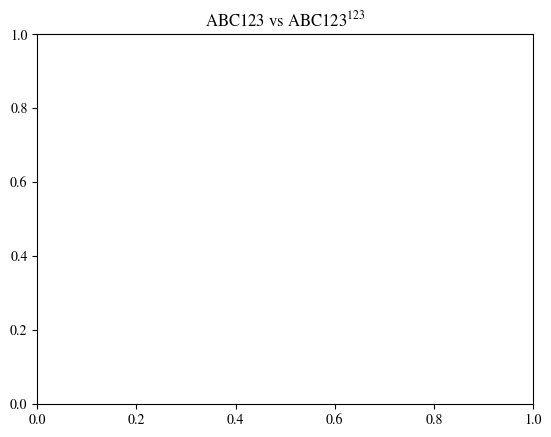

In [2]:
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.pyplot.title(r'ABC123 vs $\mathrm{ABC123}^{123}$')
plt.rcParams['font.size'] = 18
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['lines.markersize'] = 8
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['legend.frameon'] = False
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['figure.dpi'] = 150


In [3]:
torch.cuda.empty_cache()
device = autoencoder.getDevice()
print(f'Using device: {device}')
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


### Load Vlasov dataset and one trained flattened AE


In [4]:
dataset_root = Path('./vlasov_twostream_param_grid')

# Priority order for the single flattened AE trained by Train.py
model_candidates = [
    Path('./models/flat_single_ae_spa5_ep200/AE_vlasov.tar'),
    Path('./models/flat_single_ae_spa5_ep200/checkpoint_vlasov.tar'),
    Path('./models/flat_single_ae_smoke/AE_vlasov.tar'),
    Path('./models/AE_vlasov.tar'),
]

existing_models = [p for p in model_candidates if p.exists()]
if not existing_models:
    raise FileNotFoundError('No AE_vlasov model/checkpoint found in expected paths.')
model_file = existing_models[0]

# LaSDI training/evaluation setup
samples_per_axis = 4
poly_degree = 3
include_interaction = True

# Activation used in Train.py (default: swish)
activation_name = 'swish'  # 'swish' or 'sigmoid'

# Single-case visualization target: [T, k]
eval_param = np.array([1.00, 1.10], dtype=float)

if not dataset_root.exists():
    raise FileNotFoundError(dataset_root.resolve())

print(f'dataset_root: {dataset_root.resolve()}')
print(f'model_file:   {model_file.resolve()}')


dataset_root: /home/uts22/projects/ML_phisycs/LaSDI/Vlasov_twostream/vlasov_twostream_param_grid
model_file:   /home/uts22/projects/ML_phisycs/LaSDI/Vlasov_twostream/models/flat_single_ae_spa5_ep200/AE_vlasov.tar


In [5]:
sample_case = sorted(dataset_root.glob('T_*_k_*'))[0]
with np.load(sample_case / 'animation_data.npz') as data:
    f_sample = np.asarray(data['f'], dtype=np.float32)
    t = np.asarray(data['t'], dtype=float)
    x = np.asarray(data['x'], dtype=float)
    v = np.asarray(data['v'], dtype=float)

nt = f_sample.shape[0] - 1
Nx = f_sample.shape[1]
Nv = f_sample.shape[2]
dt = float(t[1] - t[0])

state = torch.load(model_file, map_location='cpu')
if 'encoder_state_dict' not in state or 'decoder_state_dict' not in state:
    raise ValueError(f'Invalid model/checkpoint format: {model_file}')

enc_state = state['encoder_state_dict']
dec_state = state['decoder_state_dict']

m = int(dec_state['full.2.weight_orig'].shape[0])
M2 = int(dec_state['full.0.weight'].shape[0])
f_latent = int(enc_state['full.2.weight'].shape[0])
M1 = int(enc_state['full.0.weight'].shape[0])

expected_m = Nx * Nv
if m != expected_m:
    raise ValueError(f'Model input dim m={m} does not match dataset Nx*Nv={expected_m}')

# Reconstruct one valid (b, db) pair for createAE.
# Since M2 = b + (m-1)*db and Train.py default db=1, this recovers b exactly for default setup.
db = 1
b = M2 - (m - 1) * db
if b <= 0:
    raise ValueError(f'Invalid derived mask params from model dims: b={b}, db={db}')

mask = lasdiutils.create_mask_1d(m, b, db)

if activation_name == 'sigmoid':
    f_activation = nn.Sigmoid
elif activation_name == 'swish':
    f_activation = autoencoder.SiLU
else:
    raise ValueError("activation_name must be 'swish' or 'sigmoid'")

encoder, decoder = autoencoder.readAEFromFile(
    autoencoder.Encoder,
    autoencoder.Decoder,
    f_activation,
    mask,
    m,
    f_latent,
    M1,
    M2,
    device,
    str(model_file),
)

print(f'sample case: {sample_case.name}')
print(f'f shape: {f_sample.shape} (Nt+1, Nx, Nv)')
print(f'dt = {dt:.5f}, t in [{t[0]:.3f}, {t[-1]:.3f}], nt = {nt}')
print(f'AE dims: m={m}, f={f_latent}, M1={M1}, M2={M2}, b={b}, db={db}')


Sparsity in 16384 by 16391 mask: 99.95%


KeyboardInterrupt: 

### Build latent-space trajectories for LaSDI dynamics training


In [ ]:
CASE_NAME_RE = re.compile(r'^T_([-+0-9.eE]+)_k_([-+0-9.eE]+)$')


def discover_cases(root: Path):
    cases = []
    for case_dir in sorted(root.iterdir()):
        if not case_dir.is_dir():
            continue
        match = CASE_NAME_RE.match(case_dir.name)
        if match is None:
            continue
        dist_path = case_dir / 'distribution_full.npz'
        if not dist_path.exists():
            continue
        cases.append(
            {
                'T': float(match.group(1)),
                'k': float(match.group(2)),
                'path': dist_path,
                'name': case_dir.name,
            }
        )
    if not cases:
        raise RuntimeError(f'No valid Vlasov cases found under: {root.resolve()}')
    return cases


def select_cases(cases, samples_per_axis=5):
    if samples_per_axis <= 0:
        return list(cases)

    T_values = np.array(sorted({c['T'] for c in cases}), dtype=float)
    k_values = np.array(sorted({c['k'] for c in cases}), dtype=float)

    if samples_per_axis > len(T_values) or samples_per_axis > len(k_values):
        raise ValueError('samples_per_axis exceeds available T-k grid size')

    T_idx = np.round(np.linspace(0, len(T_values) - 1, samples_per_axis)).astype(int)
    k_idx = np.round(np.linspace(0, len(k_values) - 1, samples_per_axis)).astype(int)
    T_idx = np.asarray(list(dict.fromkeys(T_idx.tolist())), dtype=int)
    k_idx = np.asarray(list(dict.fromkeys(k_idx.tolist())), dtype=int)

    target_pairs = {(float(T_values[i]), float(k_values[j])) for i in T_idx for j in k_idx}
    selected = [c for c in cases if (c['T'], c['k']) in target_pairs]
    selected.sort(key=lambda c: (c['T'], c['k']))

    if not selected:
        raise RuntimeError('No cases selected for dynamics training')
    return selected


all_cases = discover_cases(dataset_root)
train_cases = select_cases(all_cases, samples_per_axis=samples_per_axis)
case_map = {(round(c['T'], 2), round(c['k'], 2)): c for c in all_cases}

print(f'Total cases found: {len(all_cases)}')
print(f'Cases used for LaSDI dynamics: {len(train_cases)}')
print('First 5 training cases:', [c['name'] for c in train_cases[:5]])


Total cases found: 441
Cases used for LaSDI dynamics: 25
First 5 training cases: ['T_0.90_k_1.00', 'T_0.90_k_1.05', 'T_0.90_k_1.10', 'T_0.90_k_1.15', 'T_0.90_k_1.20']


In [ ]:
latent_space_SS = []
params = []

for idx, case in enumerate(train_cases, start=1):
    with np.load(case['path']) as data:
        f_case = np.asarray(data['f'], dtype=np.float32)

    if f_case.shape[1] != Nx or f_case.shape[2] != Nv:
        raise ValueError(f"Unexpected spatial shape in {case['path']}: {f_case.shape}")

    # Use the first (nt+1) snapshots and flatten (x,v) -> one vector in R^(Nx*Nv).
    f_case = f_case[: nt + 1]
    snapshots_flat = f_case.reshape(f_case.shape[0], -1)

    ls_traj_list = autoencoder.encodedSnapshots(encoder, snapshots_flat, nt + 1, device)
    if len(ls_traj_list) != 1:
        raise RuntimeError(f'Expected one latent trajectory per case, got {len(ls_traj_list)}')

    latent_space_SS.extend(ls_traj_list)
    params.append(np.array([case['T'], case['k']], dtype=float))

    if idx % 5 == 0 or idx == len(train_cases):
        print(f'[latent] processed {idx}/{len(train_cases)} cases')

P = np.asarray(params, dtype=float)

print(f'latent trajectories: {len(latent_space_SS)}')
print(f'P shape: {P.shape}')


[latent] processed 5/25 cases
[latent] processed 10/25 cases
[latent] processed 15/25 cases
[latent] processed 20/25 cases
[latent] processed 25/25 cases
latent trajectories: 25
P shape: (25, 2)


### Train LaSDI dynamics model in latent space


In [ ]:
normal = np.amax(np.abs(np.concatenate(latent_space_SS, axis=0)))
LaSDI_model = LaSDI(encoder, decoder, NN=True, device=device)
LaSDI_model.train_dynamics(
    latent_space_SS,
    P,
    dt,
    degree=poly_degree,
    include_interaction=include_interaction,
    normal=normal,
    LS_vis=False,
)


### Reconstruct one Vlasov case and check error history


In [ ]:
def reconstruct_case(T, k, time_stride=1):
    key = (round(float(T), 2), round(float(k), 2))
    if key not in case_map:
        raise KeyError(f'Case T={T}, k={k} is not available in dataset')

    with np.load(case_map[key]['path']) as data:
        f_true_full = np.asarray(data['f'], dtype=np.float32)
        t_full = np.asarray(data['t'], dtype=float)
        x_case = np.asarray(data['x'], dtype=float)
        v_case = np.asarray(data['v'], dtype=float)

    stride = max(1, int(time_stride))
    time_indices = np.arange(0, len(t_full), stride, dtype=int)
    t_eval = t_full[time_indices]

    f_true = f_true_full[time_indices]
    pred_ic = f_true_full[0].reshape(-1).astype(np.float32)

    param = np.array([float(T), float(k)], dtype=float)
    pred_flat = LaSDI_model.generate_ROM(pred_ic, param, t_eval)
    pred_flat = np.asarray(pred_flat, dtype=np.float32)

    n_t = min(f_true.shape[0], pred_flat.shape[0])
    f_true = f_true[:n_t]
    t_eval = t_eval[:n_t]
    f_pred = pred_flat[:n_t].reshape(n_t, Nx, Nv)

    true_flat = f_true.reshape(n_t, -1)
    pred_flat = f_pred.reshape(n_t, -1)
    denom = np.maximum(np.linalg.norm(true_flat, axis=1), 1.0e-12)
    rel_t = np.linalg.norm(pred_flat - true_flat, axis=1) / denom

    return {
        'T': float(T),
        'k': float(k),
        't': t_eval,
        'x': x_case,
        'v': v_case,
        'f_true': f_true,
        'f_pred': f_pred,
        'rel_t': rel_t,
    }


start = time.time()
result_eval = reconstruct_case(eval_param[0], eval_param[1], time_stride=1)
recon_time = time.time() - start

print(f"Reconstruction finished in {recon_time:.2f} s for T={result_eval['T']:.2f}, k={result_eval['k']:.2f}")
print(f"Max relative error: {100.0 * np.max(result_eval['rel_t']):.3f}%")


TypeError: SINDy.fit() got an unexpected keyword argument 'multiple_trajectories'

### Latent-space dynamics comparison (prediction vs encoded ground truth)


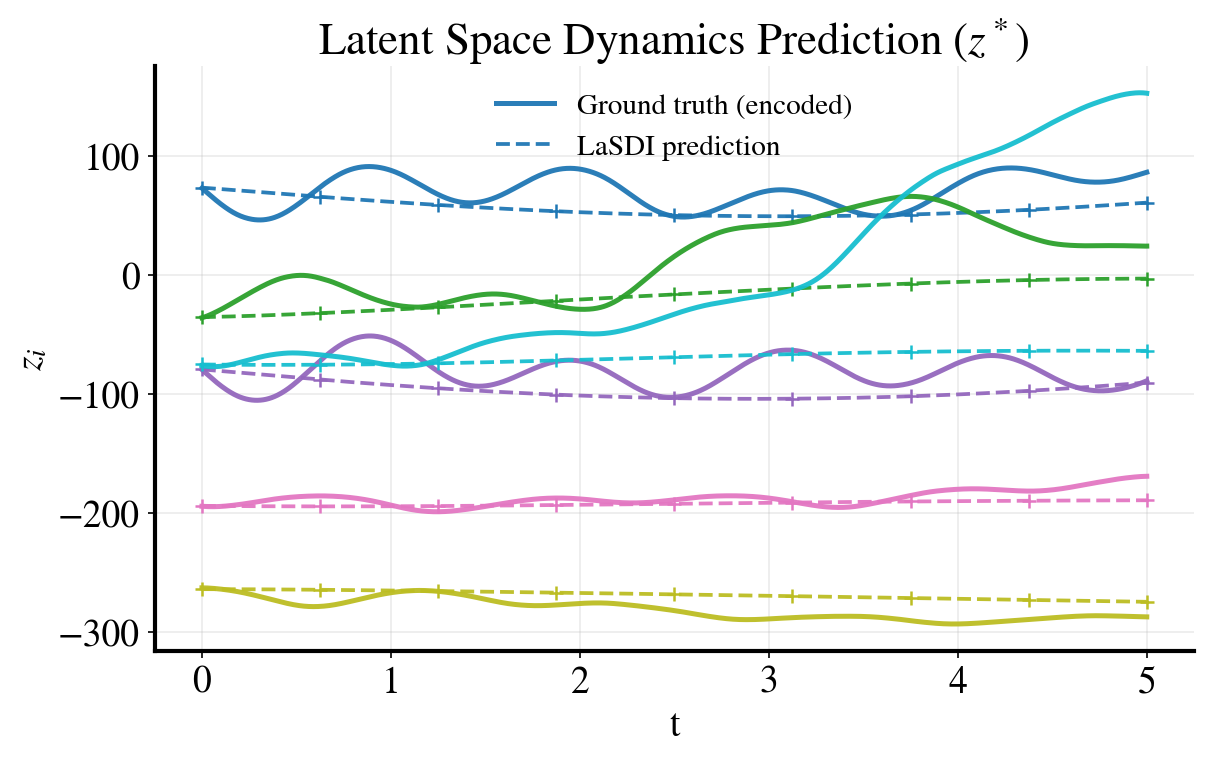

Saved latent comparison image to: /home/uts22/projects/ML_phisycs/LaSDI/Vlasov_twostream/results/latent_dynamics_compare_T1.00_k1.10.png
Saved latent comparison data  to: /home/uts22/projects/ML_phisycs/LaSDI/Vlasov_twostream/results/latent_dynamics_compare_T1.00_k1.10.npz


In [ ]:
n_t_eval = result_eval['t'].shape[0]
true_flat_eval = result_eval['f_true'].reshape(n_t_eval, -1)
pred_flat_eval = result_eval['f_pred'].reshape(n_t_eval, -1)

z_true = autoencoder.encodedSnapshots(encoder, true_flat_eval, n_t_eval, device)[0]
z_pred = autoencoder.encodedSnapshots(encoder, pred_flat_eval, n_t_eval, device)[0]

n_dims_plot = min(8, z_true.shape[1])
colors = plt.cm.tab10(np.linspace(0.0, 1.0, n_dims_plot))

fig, ax = plt.subplots(figsize=(8.4, 5.4))
for dim in range(n_dims_plot):
    ax.plot(
        result_eval['t'],
        z_true[:, dim],
        color=colors[dim],
        lw=2.4,
        alpha=0.95,
        label='Ground truth (encoded)' if dim == 0 else '_nolegend_',
    )
    ax.plot(
        result_eval['t'],
        z_pred[:, dim],
        '--',
        color=colors[dim],
        lw=1.8,
        alpha=0.95,
        label='LaSDI prediction' if dim == 0 else '_nolegend_',
    )

    marker_step = max(1, n_t_eval // 8)
    ax.plot(
        result_eval['t'][::marker_step],
        z_pred[::marker_step, dim],
        linestyle='None',
        marker='+',
        markersize=7,
        markeredgewidth=1.2,
        color=colors[dim],
        label='_nolegend_',
    )

ax.set_title(r'Latent Space Dynamics Prediction ($z^*$)')
ax.set_xlabel('t')
ax.set_ylabel(r'$z_i$')
ax.grid(alpha=0.25)
ax.legend(loc='best')
fig.tight_layout()

out_dir = Path('results')
out_dir.mkdir(parents=True, exist_ok=True)
out_img = out_dir / f"latent_dynamics_compare_T{result_eval['T']:.2f}_k{result_eval['k']:.2f}.png"
out_npz = out_dir / f"latent_dynamics_compare_T{result_eval['T']:.2f}_k{result_eval['k']:.2f}.npz"
fig.savefig(out_img, dpi=300)
np.savez(
    out_npz,
    t=result_eval['t'],
    z_true=z_true,
    z_pred=z_pred,
    T=np.array([result_eval['T']], dtype=float),
    k=np.array([result_eval['k']], dtype=float),
)
plt.show()

print(f'Saved latent comparison image to: {out_img.resolve()}')
print(f'Saved latent comparison data  to: {out_npz.resolve()}')


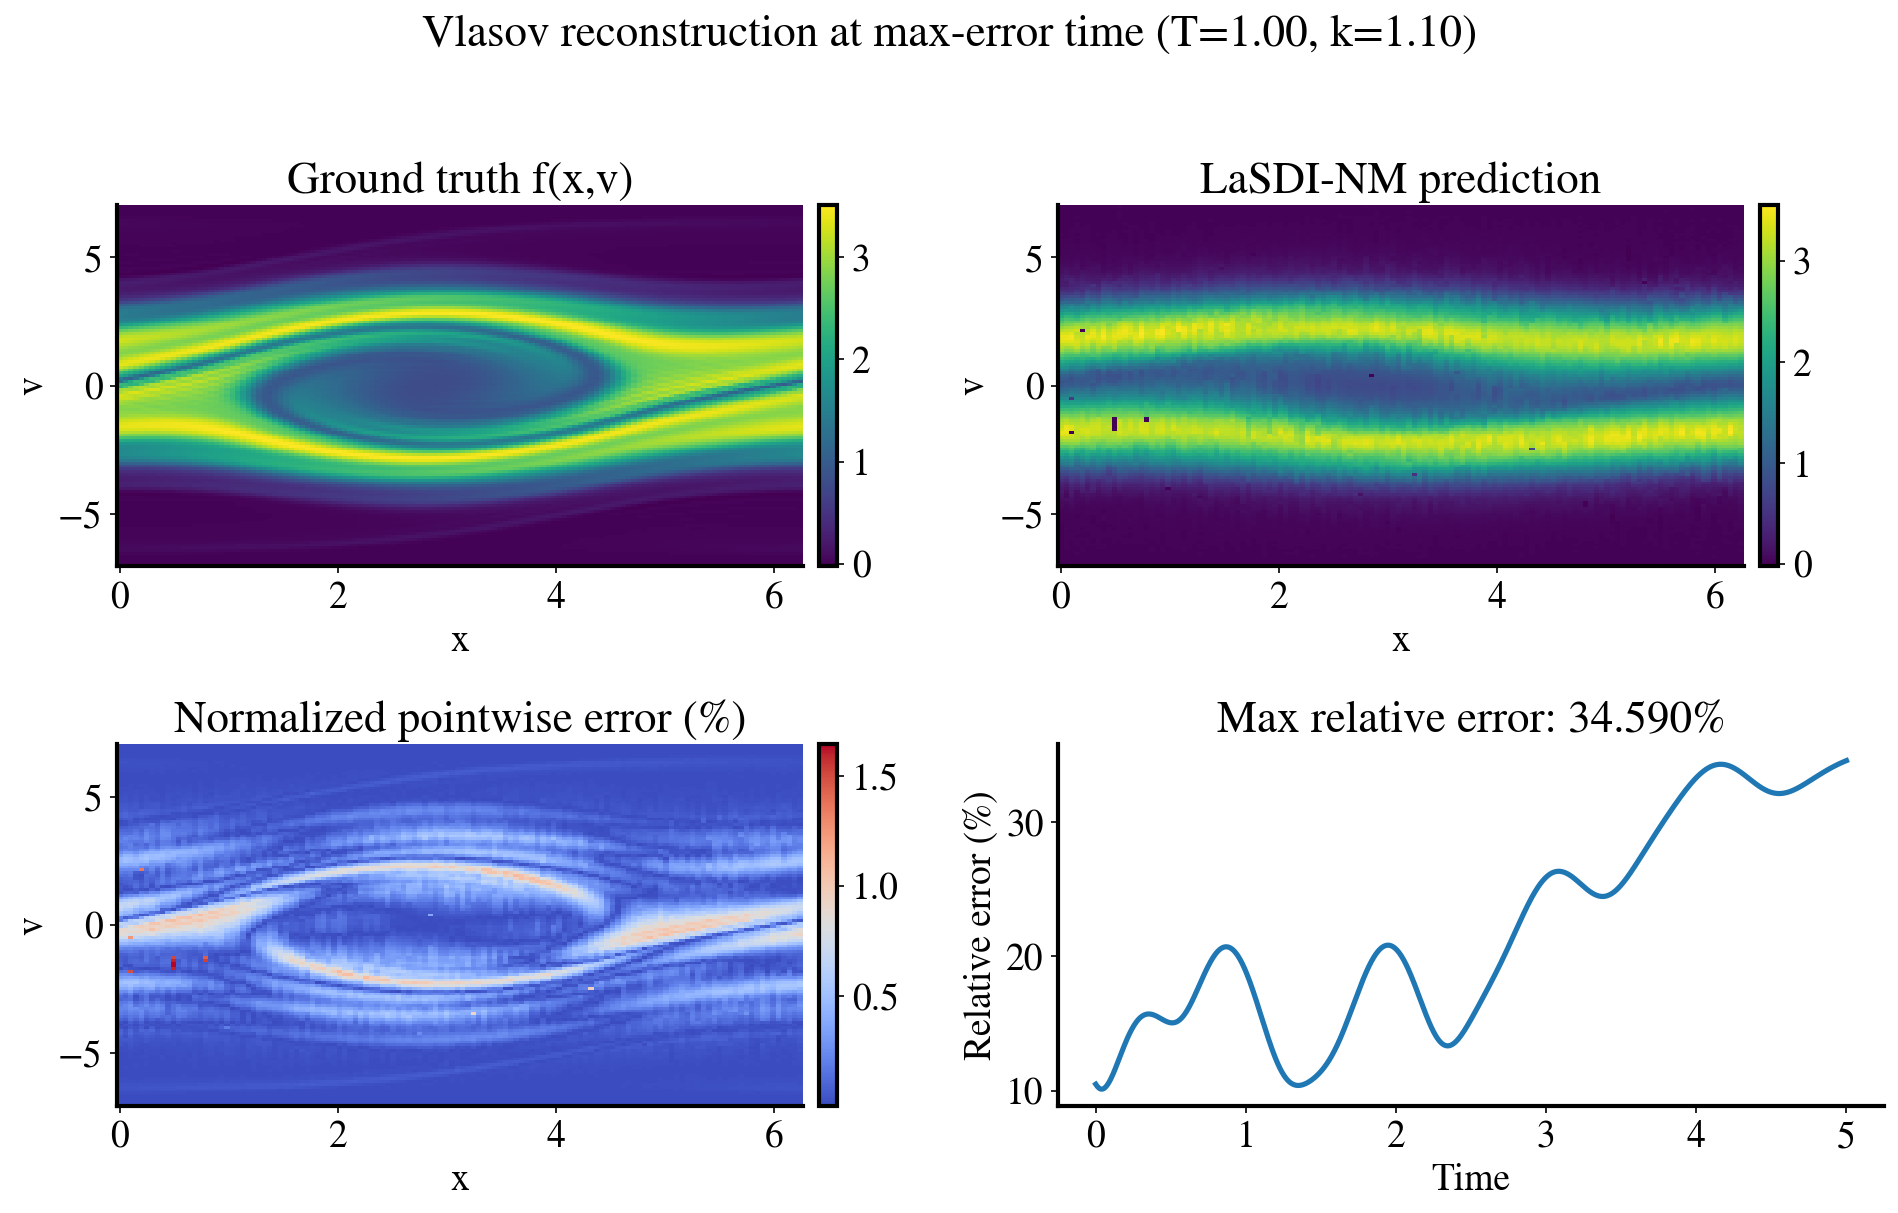

In [ ]:
k_max = int(np.argmax(result_eval['rel_t']))

X, V = np.meshgrid(result_eval['x'], result_eval['v'], indexing='xy')
true_snapshot = result_eval['f_true'][k_max]
pred_snapshot = result_eval['f_pred'][k_max]
field_err = np.abs(pred_snapshot - true_snapshot)
field_err /= max(LA.norm(true_snapshot), 1.0e-12)

fig = plt.figure(figsize=(13, 8))
fig.suptitle(
    f"Vlasov reconstruction at max-error time (T={result_eval['T']:.2f}, k={result_eval['k']:.2f})",
    y=1.02,
)

ax1 = fig.add_subplot(2, 2, 1)
z1 = ax1.pcolormesh(X, V, true_snapshot.T, shading='auto')
fig.colorbar(z1, ax=ax1, pad=0.02)
ax1.set_title('Ground truth f(x,v)')
ax1.set_xlabel('x')
ax1.set_ylabel('v')

ax2 = fig.add_subplot(2, 2, 2)
z2 = ax2.pcolormesh(X, V, pred_snapshot.T, shading='auto')
fig.colorbar(z2, ax=ax2, pad=0.02)
ax2.set_title('LaSDI-NM prediction')
ax2.set_xlabel('x')
ax2.set_ylabel('v')

ax3 = fig.add_subplot(2, 2, 3)
z3 = ax3.pcolormesh(X, V, field_err.T * 100.0, shading='auto', cmap='coolwarm')
fig.colorbar(z3, ax=ax3, pad=0.02)
ax3.set_title('Normalized pointwise error (%)')
ax3.set_xlabel('x')
ax3.set_ylabel('v')

ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(result_eval['t'], 100.0 * result_eval['rel_t'])
ax4.set_xlabel('Time')
ax4.set_ylabel('Relative error (%)')
ax4.set_title(f"Max relative error: {100.0*np.max(result_eval['rel_t']):.3f}%")

fig.tight_layout()
plt.show()


## Error Map on Full 21x21 Grid (441 cases)


In [ ]:
# For faster execution, use time_stride>1.
error_map_time_stride = 5

params_all = np.asarray([[c['T'], c['k']] for c in all_cases], dtype=float)
T_values = np.sort(np.unique(params_all[:, 0]))
k_values = np.sort(np.unique(params_all[:, 1]))

T_index = {float(T): j for j, T in enumerate(T_values)}
k_index = {float(k): i for i, k in enumerate(k_values)}
error_grid = np.full((k_values.size, T_values.size), np.nan, dtype=float)

start = time.time()
for idx, case in enumerate(all_cases, start=1):
    result = reconstruct_case(
        case['T'],
        case['k'],
        time_stride=error_map_time_stride,
    )
    err_percent = 100.0 * np.max(result['rel_t'])
    error_grid[k_index[float(case['k'])], T_index[float(case['T'])]] = err_percent

    if idx % 25 == 0 or idx == len(all_cases):
        elapsed = time.time() - start
        print(f'[error-map] processed {idx}/{len(all_cases)}  elapsed={elapsed:.1f}s')


def _cell_edges(values):
    if values.size == 1:
        v0 = float(values[0])
        return np.array([v0 - 0.5, v0 + 0.5], dtype=float)
    mids = 0.5 * (values[:-1] + values[1:])
    left = values[0] - 0.5 * (values[1] - values[0])
    right = values[-1] + 0.5 * (values[-1] - values[-2])
    return np.concatenate([[left], mids, [right]])


def _select_training_params_5x5(T_vals, k_vals, samples_per_axis=5):
    if samples_per_axis <= 0:
        raise ValueError('samples_per_axis must be positive')
    if samples_per_axis > len(T_vals) or samples_per_axis > len(k_vals):
        raise ValueError('samples_per_axis exceeds available grid size')

    T_idx = np.round(np.linspace(0, len(T_vals) - 1, samples_per_axis)).astype(int)
    k_idx = np.round(np.linspace(0, len(k_vals) - 1, samples_per_axis)).astype(int)
    T_idx = np.asarray(list(dict.fromkeys(T_idx.tolist())), dtype=int)
    k_idx = np.asarray(list(dict.fromkeys(k_idx.tolist())), dtype=int)

    train_params = np.array(
        [(float(T_vals[i]), float(k_vals[j])) for i in T_idx for j in k_idx],
        dtype=float,
    )
    return train_params


T_edges = _cell_edges(T_values)
k_edges = _cell_edges(k_values)

fig, ax = plt.subplots(figsize=(12, 9))
mesh = ax.pcolormesh(
    T_edges,
    k_edges,
    error_grid,
    shading='auto',
    cmap='coolwarm',
    vmin=0.0,
    vmax=float(np.nanmax(error_grid) if np.any(~np.isnan(error_grid)) else 1.0),
)

for i, k in enumerate(k_values):
    for j, T in enumerate(T_values):
        value = error_grid[i, j]
        if np.isnan(value):
            continue
        ax.text(float(T), float(k), f'{value:.1f}', ha='center', va='center', fontsize=7, color='black')

train_params_25 = _select_training_params_5x5(T_values, k_values, samples_per_axis=5)
ax.scatter(
    train_params_25[:, 0],
    train_params_25[:, 1],
    marker='s',
    s=180,
    facecolors='none',
    edgecolors='black',
    linewidths=1.6,
)

ax.set_xlabel('Temperature T')
ax.set_ylabel('Wavenumber k')
ax.set_title('LaSDI-NM Error Map on Vlasov Full Grid (max relative error %)')

cbar = fig.colorbar(mesh, ax=ax, pad=0.02)
cbar.set_label('Maximum relative error (%)')
fig.tight_layout()

out_dir = Path('results')
out_dir.mkdir(parents=True, exist_ok=True)
out_img = out_dir / 'lasdi_vlasov_error_map_full_grid.png'
out_npz = out_dir / 'lasdi_vlasov_error_map_full_grid.npz'
fig.savefig(out_img, dpi=300)
np.savez(
    out_npz,
    T_values=T_values,
    k_values=k_values,
    max_rel_err_percent=error_grid,
    train_params=train_params_25,
    eval_params=params_all,
    time_stride=np.array([error_map_time_stride], dtype=int),
)
plt.show()

print(f'Saved error map image to: {out_img.resolve()}')
print(f'Saved error map data  to: {out_npz.resolve()}')


KeyboardInterrupt: 